# Comparing ERA5 sources - CDS vs EDH

`atlite` offers two sources for the ERA5 dataset - CDS and EDH. ERA5 is natively hosted on the Copernicus Data Store, which offers many convenient options for server-side processing of the raw ERA5 data. However, it can only serve 400 simultaneous requests, so you often have to wait for hours in order to download data, which can be annoying and difficult to debug. 

The Earth Data Hub hosts a mirror of ERA5. They do not have a queue (although they still require authentication, see [installation instructions](https://atlite.readthedocs.io/en/master/installation.html)). However, they offer limited server-side processing, which means you need to download a bit more data, and do more processing on device. Some of the CDS server-side processing is difficult to mimic locally, especially interpolation to grids other than the default 0.25x0.25 deg grid, so, for a limited subset of users, CDS is the only source.

This table summarises the differences between the two datasets:

|                      | CDS                  | EDH          |
|----------------------|----------------------|---------------|
| atlite API           | same                 | same          |
| authentication/setup | API + accept license | API + accept license |
| download queue       | 5min-8hrs            | none          |
| cutout size          | 1x                   | 1x            |
| download size        | 1x                   | ~1.5x         |
| data storage grid    | parameter-dependent  | 0.25 deg. grid |
| results at 0.25 deg. grid    | reference | within 1.5% (worst-case) |



> **So which source should I use?** For very large cutouts (e.g. continents larger than Europe), for workflows that already used CDS, and when you require data at resolution that is not a multiple of the default 0.25/0.25 deg. grid, use CDS. For everything else, EDH is more convenient.

In this example we will demonstrate how to use the EDH mirror of the ERA5 dataset within `atlite` and the minimal numerical differences between them. For a more detailed explanation on how to build cutouts, follow [this notebook](https://atlite.readthedocs.io/en/master/examples/create_cutout.html).

We start with the setup:

In [1]:
import warnings
from pathlib import Path

import numpy as np
import xarray as xr

import atlite

warnings.filterwarnings("ignore")

Let's download cutouts from both sources:

In [6]:
TIME = "2013-01-01"
BOUNDS = (-4, 56, 1.5, 62)
CACHE = Path(".cache")
CACHE.mkdir(exist_ok=True)

cutout_CDS = atlite.Cutout(
    path=CACHE / "era5-cds-native.nc",
    module="era5",
    bounds=BOUNDS,
    time=TIME,
)
cutout_CDS.prepare()

<Cutout "era5-cds-native">
 x = -4.00 ⟷ 1.50, dx = 0.25
 y = 56.00 ⟷ 62.00, dy = 0.25
 time = 2013-01-01 ⟷ 2013-01-01, dt = h
 module = era5
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

In [3]:
cutout_EDH = atlite.Cutout(
    path=CACHE / "era5-edh-native.nc",
    module="era5-edh",
    bounds=BOUNDS,
    time=TIME,
)
cutout_EDH.prepare(tmpdir=CACHE)

<Cutout "era5-edh-native">
 x = -4.00 ⟷ 1.50, dx = 0.25
 y = 56.00 ⟷ 62.00, dy = 0.25
 time = 2013-01-01 ⟷ 2013-01-01, dt = h
 module = era5-edh
 prepared_features = ['height', 'wind', 'influx', 'temperature', 'runoff']

As you can see, the API for both datasets is identical. The only change needed is replacing `module="era5"` with `module="era5-edh"`. EDH provides the same atlite-facing functionality, except that it only works at 0.25x0.25 deg resolution. Now let's investigate if the datasets provide the same data:

In [4]:
common_vars = set(cutout_CDS.data.data_vars) & set(cutout_EDH.data.data_vars)

print(
    "Both cutouts have the same features:",
    common_vars == set(cutout_CDS.data.data_vars),
)

rtol = 1.5e-2
try:
    xr.testing.assert_allclose(
        cutout_CDS.data[common_vars], cutout_EDH.data[common_vars], rtol=rtol
    )
    print(f"Data in both sources matches within tolerance ({rtol * 100}%)")
except Exception:
    print("Data in both features is NOT identical")

Both cutouts have the same features: True
Data in both sources matches within tolerance (1.5%)


The two datasets match well enough for atlite use (within 1.5%). The source of error is lossy compression on the EDH side. They use a [bitround](https://numcodecs.readthedocs.io/en/latest/filter/bitround.html) filter, which only stores 10 bits of each variable. The result is worst for height and temperature variables, as you can see below:

In [7]:
diff = abs(cutout_CDS.data[common_vars] - cutout_EDH.data[common_vars])
max_diff = diff.max().compute()
print(max_diff.to_pandas())

influx_diffuse          1.066666e-01
roughness               2.440810e-04
wnd_azimuth             4.093647e-04
temperature             1.250000e-01
albedo                  8.535162e-04
dewpoint temperature    1.250000e-01
wnd100m                 7.616043e-03
height                  1.690674e-01
influx_direct           3.556061e-02
solar_azimuth           2.384101e-07
wnd_shear_exp           3.905668e-04
solar_altitude          2.980201e-08
soil temperature        1.248779e-01
influx_toa              7.113647e-02
runoff                  0.000000e+00
dtype: float64


We can also plot relative differences on a graph:

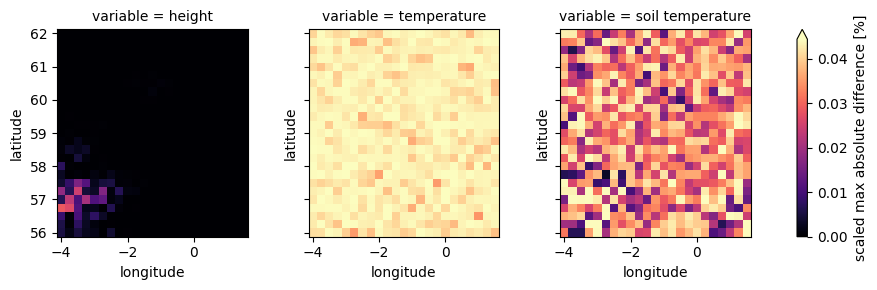

In [11]:
WORST_DIFF_VARS = [
    "height",
    "temperature",
    "soil temperature",
]


def scaled_max_abs_diff(reference, candidate):
    diff = np.abs(candidate - reference)
    scale = float(np.maximum(np.abs(reference), np.abs(candidate)).max(skipna=True))
    reduce_dims = [dim for dim in diff.dims if dim not in {"x", "y"}]
    diff_map = diff.max(dim=reduce_dims, skipna=True) if reduce_dims else diff
    return 100 * diff_map.fillna(0) / scale


diff_maps = [
    scaled_max_abs_diff(
        cutout_CDS.data[var],
        cutout_EDH.data[var],
    ).assign_coords(variable=var)
    for var in WORST_DIFF_VARS
]

relative_max_diff = xr.concat(diff_maps, dim="variable").rename(
    "scaled max absolute difference [%]"
)

grid = relative_max_diff.plot.pcolormesh(
    x="x",
    y="y",
    col="variable",
    col_wrap=3,
    cmap="magma",
    robust=True,
    cbar_kwargs={"label": "scaled max absolute difference [%]"},
)

for ax in grid.axs.flat:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

Once we actually calculate the renewable potentials, all the quantisations average out, resulting in a smaller relative difference. Over larger time and space the differences are negligible. Here is the 99-percentile difference in pv and wind capacity factors between CDS and EDH over Europe in 2013:

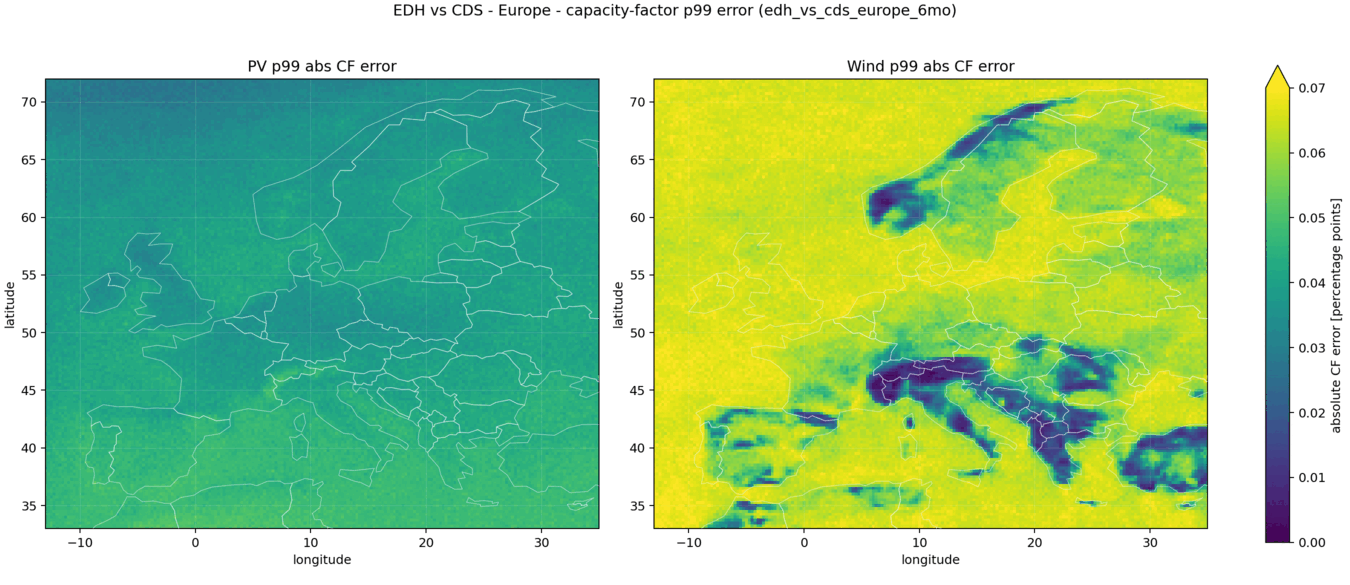

Hopefully that quells any doubts you may have had about using EDH data. And you learned a bit about compression as well!

> **The conclusion once again:** For very large cutouts (e.g. continents larger than Europe), for workflows that already used CDS, and when you require data at resolution that is not a multiple of 0.25/0.25 deg. grid, use CDS. For everything else, EDH is more convenient. And the change from one to another is a single line of code.